# 2. Hafta — Belirme ve Hücresel Otomatların Sınıflandırılması

**Proje:** Hücresel Otomatlarda Beliren Karmaşıklık  
**Not defteri:** `02_rule_classification.ipynb`  
**Tahmini süre:** 8–10 saat

Geçen hafta dört temel hücresel otomatı sıfırdan oluşturup karşılaştırdın. Bu hafta dört örnekten **256 kuralın sistematik incelenmesine** geçiyoruz.

Ana araştırma sorumuz:

> **Hücresel otomatları büyük ölçekli davranışlarına göre sınıflandırabilir miyiz ve sayısal ölçümler resimlerin söylemediği neyi gösterebilir?**

Bu hafta önemli bir bilimsel alışkanlık geliştireceğiz: önce gözlem yapacak, sonra sınıflandırma ölçütlerimizi açıkça yazacak ve en son ölçümlerle yorumlarımızı sınayacağız.

## Öğrenme hedefleri

Bu not defterinin sonunda şunları yapabilmelisin:

1. aynı başlangıç koşulundan 256 ECA kuralını üretmek;
2. tekrarlanabilir rastgele başlangıç koşulları oluşturmak;
3. Wolfram'ın dört nitel sınıfını örneklerle açıklamak;
4. yoğunluk \(\rho(t)\) ve etkinlik \(a(t)\) ölçümlerini hesaplamak;
5. bir görsel sınıflandırmayı ölçülebilir kanıtlarla savunmak;
6. bir kuralın görünüşünün başlangıç koşuluna bağlı olabileceğini göstermek.

### Bilimsel iş akışı

\[
\boxed{\text{Soru} \rightarrow \text{Deney protokolü} \rightarrow
\text{Gözlem} \rightarrow \text{Ölçüm} \rightarrow \text{Yorum}}
\]

Bu sıralamada özellikle **gözlem** ile **yorum** arasındaki farkı koru. “Kural 30'un 80 satırının 80'i farklıdır” bir gözlemdir. “Kural 30 kaotiktir” ise gözlemlere dayanan bir yorumdur.

### Baslamadan once: tahminlerini kaydet

Kodlari calistirmadan once kisa yanitlar yaz:

1. 256 kuralin cogunun duzenli mi, yoksa karmasik mi olmasini bekliyorsun? Neden?
2. Tek dolu hucre ve rastgele bir satir ayni kural icin ayni siniflandirmayi verir mi?
3. Bir desenin kaotik oldugunu yalnizca resmine bakarak soylemek guvenilir midir?

**Tahminlerim:**

> 1. Kurallarin cogunun *duzenli* (Sinif I veya II) olmasini bekliyorum, cunku 8 cikti bitini rastgele sectigimizde cogu kombinasyonun ya cok az 1 icerip hizla sonmesi ya da basit bir simetriye sahip olup periyodik bir oruntuye kilitlenmesi daha olasi gorunuyor.
> 2. Hayir, ayni siniflandirmayi vermeyebilir. Tek dolu hucre cok ozel, simetrik bir baslangic; rastgele baslangic farkli komsuluklarin hepsini bir arada sunuyor, bu yuzden gorunum degisebilir.
> 3. Hayir, tam olarak guvenilir degildir. Sonlu bir resim sonsuz zaman davranisini kanitlamaz; bu yuzden gorsel izlenimi sayisal olcumlerle birlikte kullanmak gerekiyor (ikinci yarida yapacagiz).

<details>
<summary>Dusunme ipucu</summary>

Bu sorularin tek bir hazir yaniti yoktur. Onemli olan tahminini deneyden **once** kaydetmek ve deneyden sonra neyin degistigini aciklamaktir.
</details>


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["image.cmap"] = "binary"


def check(label, test_function):
    '''Bir öğrenci testini not defterini durdurmadan çalıştır.'''
    try:
        test_function()
    except (AssertionError, NotImplementedError) as error:
        message = str(error) or "sonuç beklenen değerle eşleşmedi"
        print(f"○ {label}: çalışmaya devam et — {message}")
    else:
        print(f"✓ {label}: geçti")


print("Kurulum tamamlandı.")

Kurulum tamamlandı.


## 1. Geçen haftanın benzetim motoru

Aşağıdaki motor, 1. haftada yazdığın kodla aynı fiziksel modeli uygular. Bu hafta hedefimiz motoru yeniden yazmak değil, onu bir **deney aracı** olarak kullanmaktır.

Kural numarasının `index` numaralı bitini

```python
(rule_number >> index) & 1
```

ifadesiyle okuyoruz. `np.roll`, periyodik sınır koşullarında sol ve sağ komşuları buluyor.

In [2]:
def update_row(row, rule_number):
    '''Periyodik sınırlı bir ECA satırını bir zaman adımı ilerlet.'''
    row = np.asarray(row, dtype=np.uint8)
    left = np.roll(row, 1)
    right = np.roll(row, -1)
    indices = 4 * left + 2 * row + right
    return ((int(rule_number) >> indices) & 1).astype(np.uint8)


def simulate(initial_row, rule_number, steps):
    '''Başlangıç satırı dâhil olmak üzere uzay–zaman geçmişini döndür.'''
    initial_row = np.asarray(initial_row, dtype=np.uint8)
    history = np.zeros((steps, len(initial_row)), dtype=np.uint8)
    history[0] = initial_row
    for t in range(1, steps):
        history[t] = update_row(history[t - 1], rule_number)
    return history


def single_seed(width):
    '''Ortası dolu, diğer hücreleri boş bir satır oluştur.'''
    state = np.zeros(width, dtype=np.uint8)
    state[width // 2] = 1
    return state


assert simulate(single_seed(9), 90, 5).shape == (5, 9)
print("Benzetim motoru hazır.")

Benzetim motoru hazır.


## 2. Tekrarlanabilir rastgele başlangıç koşulu

Bir hücrenin başlangıçta dolu olma olasılığına \(p\) diyelim:

\[
P(s_i(0)=1)=p.
\]

Rastgele deneyler yaparken aynı sonucu yeniden üretebilmek için bir rastgele sayı üreteci (`rng`) kullanacağız:

```python
rng = np.random.default_rng(42)
```

Aynı tohum (`42`) aynı sayı dizisini üretir. Bu, hesaplamalı bilimin **tekrarlanabilirlik** ilkesidir.

### Alıştırma 1

`random_initial_state` fonksiyonunu tamamla. `rng.random(width)` ile \([0,1)\) aralığında sayılar üret; her sayının `density` değerinden küçük olup olmadığını karşılaştır. Sonucu `np.uint8` türüne dönüştür.

In [3]:
def random_initial_state(width, density, rng):
    '''Yaklasik verilen yogunlukta rastgele 0/1 satiri olustur.'''
    return (rng.random(width) < density).astype(np.uint8)


In [4]:
def test_random_initial_state():
    a = random_initial_state(100, 0.35, np.random.default_rng(123))
    b = random_initial_state(100, 0.35, np.random.default_rng(123))
    assert a.shape == (100,), f"beklenen biçim (100,), bulunan {a.shape}"
    assert set(np.unique(a)) <= {0, 1}, "durum yalnızca 0 ve 1 içermeli"
    assert np.array_equal(a, b), "aynı tohum aynı satırı üretmeli"
    assert random_initial_state(20, 0.0, np.random.default_rng(1)).sum() == 0, (
        "p=0 iken bütün hücreler boş olmalı"
    )
    assert random_initial_state(20, 1.0, np.random.default_rng(1)).sum() == 20, (
        "p=1 iken bütün hücreler dolu olmalı"
    )


check("Alıştırma 1 — rastgele başlangıç", test_random_initial_state)

✓ Alıştırma 1 — rastgele başlangıç: geçti


### Referans başlangıç fonksiyonu

Galerinin, alıştırman tamamlanmadan da çalışabilmesi için aşağıdaki referans fonksiyonu kullanılacaktır. Testin geçtikten sonra iki fonksiyonun aynı tohumla aynı sonucu verdiğini kendin kontrol et.

In [5]:
def _random_initial_state_reference(width, density, rng):
    return (rng.random(width) < density).astype(np.uint8)

## 3. Wolfram'ın nitel sınıfları

Stephen Wolfram, ECA davranışlarını kabaca dört grupta ele almıştır:

| Sınıf | Tipik uzun-zaman davranışı | Görsel ipuçları |
|---:|---|---|
| I | Homojen duruma yaklaşır | Tamamen boş veya tamamen dolu hâle gelme |
| II | Sabit ya da periyodik yapılar | Tekrarlanan satırlar, çizgiler, küçük salınımlar |
| III | Kaotik görünümlü davranış | Düzensiz doku, uzun süre devam eden değişim |
| IV | Karmaşık ve yerel yapılar | Düzenli arka plan üzerinde etkileşen/hareket eden yapılar |

Bu tablo kesin bir otomatik algoritma değildir. Sonlu bir resim, sonsuz-zaman davranışını kanıtlamaz. Ayrıca farklı başlangıç koşulları aynı kuralın farklı özelliklerini gösterebilir.

<details>
<summary>Soru: “61 satırın 61'i farklı” olması tek başına Sınıf III'ü kanıtlar mı?</summary>

Hayır. Uzun geçici davranış gösteren Sınıf IV benzeri bir kuralda da bütün satırlar farklı olabilir. Tek bir ölçümü kesin bir etiket olarak değil, bir kanıt parçası olarak kullanmalıyız.
</details>

<details>
<summary>Soru: Neden sınıflandırma yapmadan önce başlangıç koşulunu belirtmeliyiz?</summary>

Çünkü gözlediğimiz dinamik hem kurala hem başlangıç durumuna bağlıdır. Örneğin bütün hücreleri boş bir başlangıç, birçok ilginç kural için tamamen boş kalabilir ve kuralın zengin davranışını gizleyebilir.
</details>

## 4. 256 kuralın galerisi

Adil bir karşılaştırma için bütün kurallarda şu değişkenleri sabit tutacağız:

- genişlik: 101 hücre;
- süre: 80 zaman adımı;
- başlangıç yoğunluğu: \(p=0.5\);
- rastgele tohum: 42;
- sınır koşulu: periyodik.

Burada **aynı başlangıç satırını** bütün kurallara veriyoruz. Böylece değişen tek şey kural numarası oluyor.

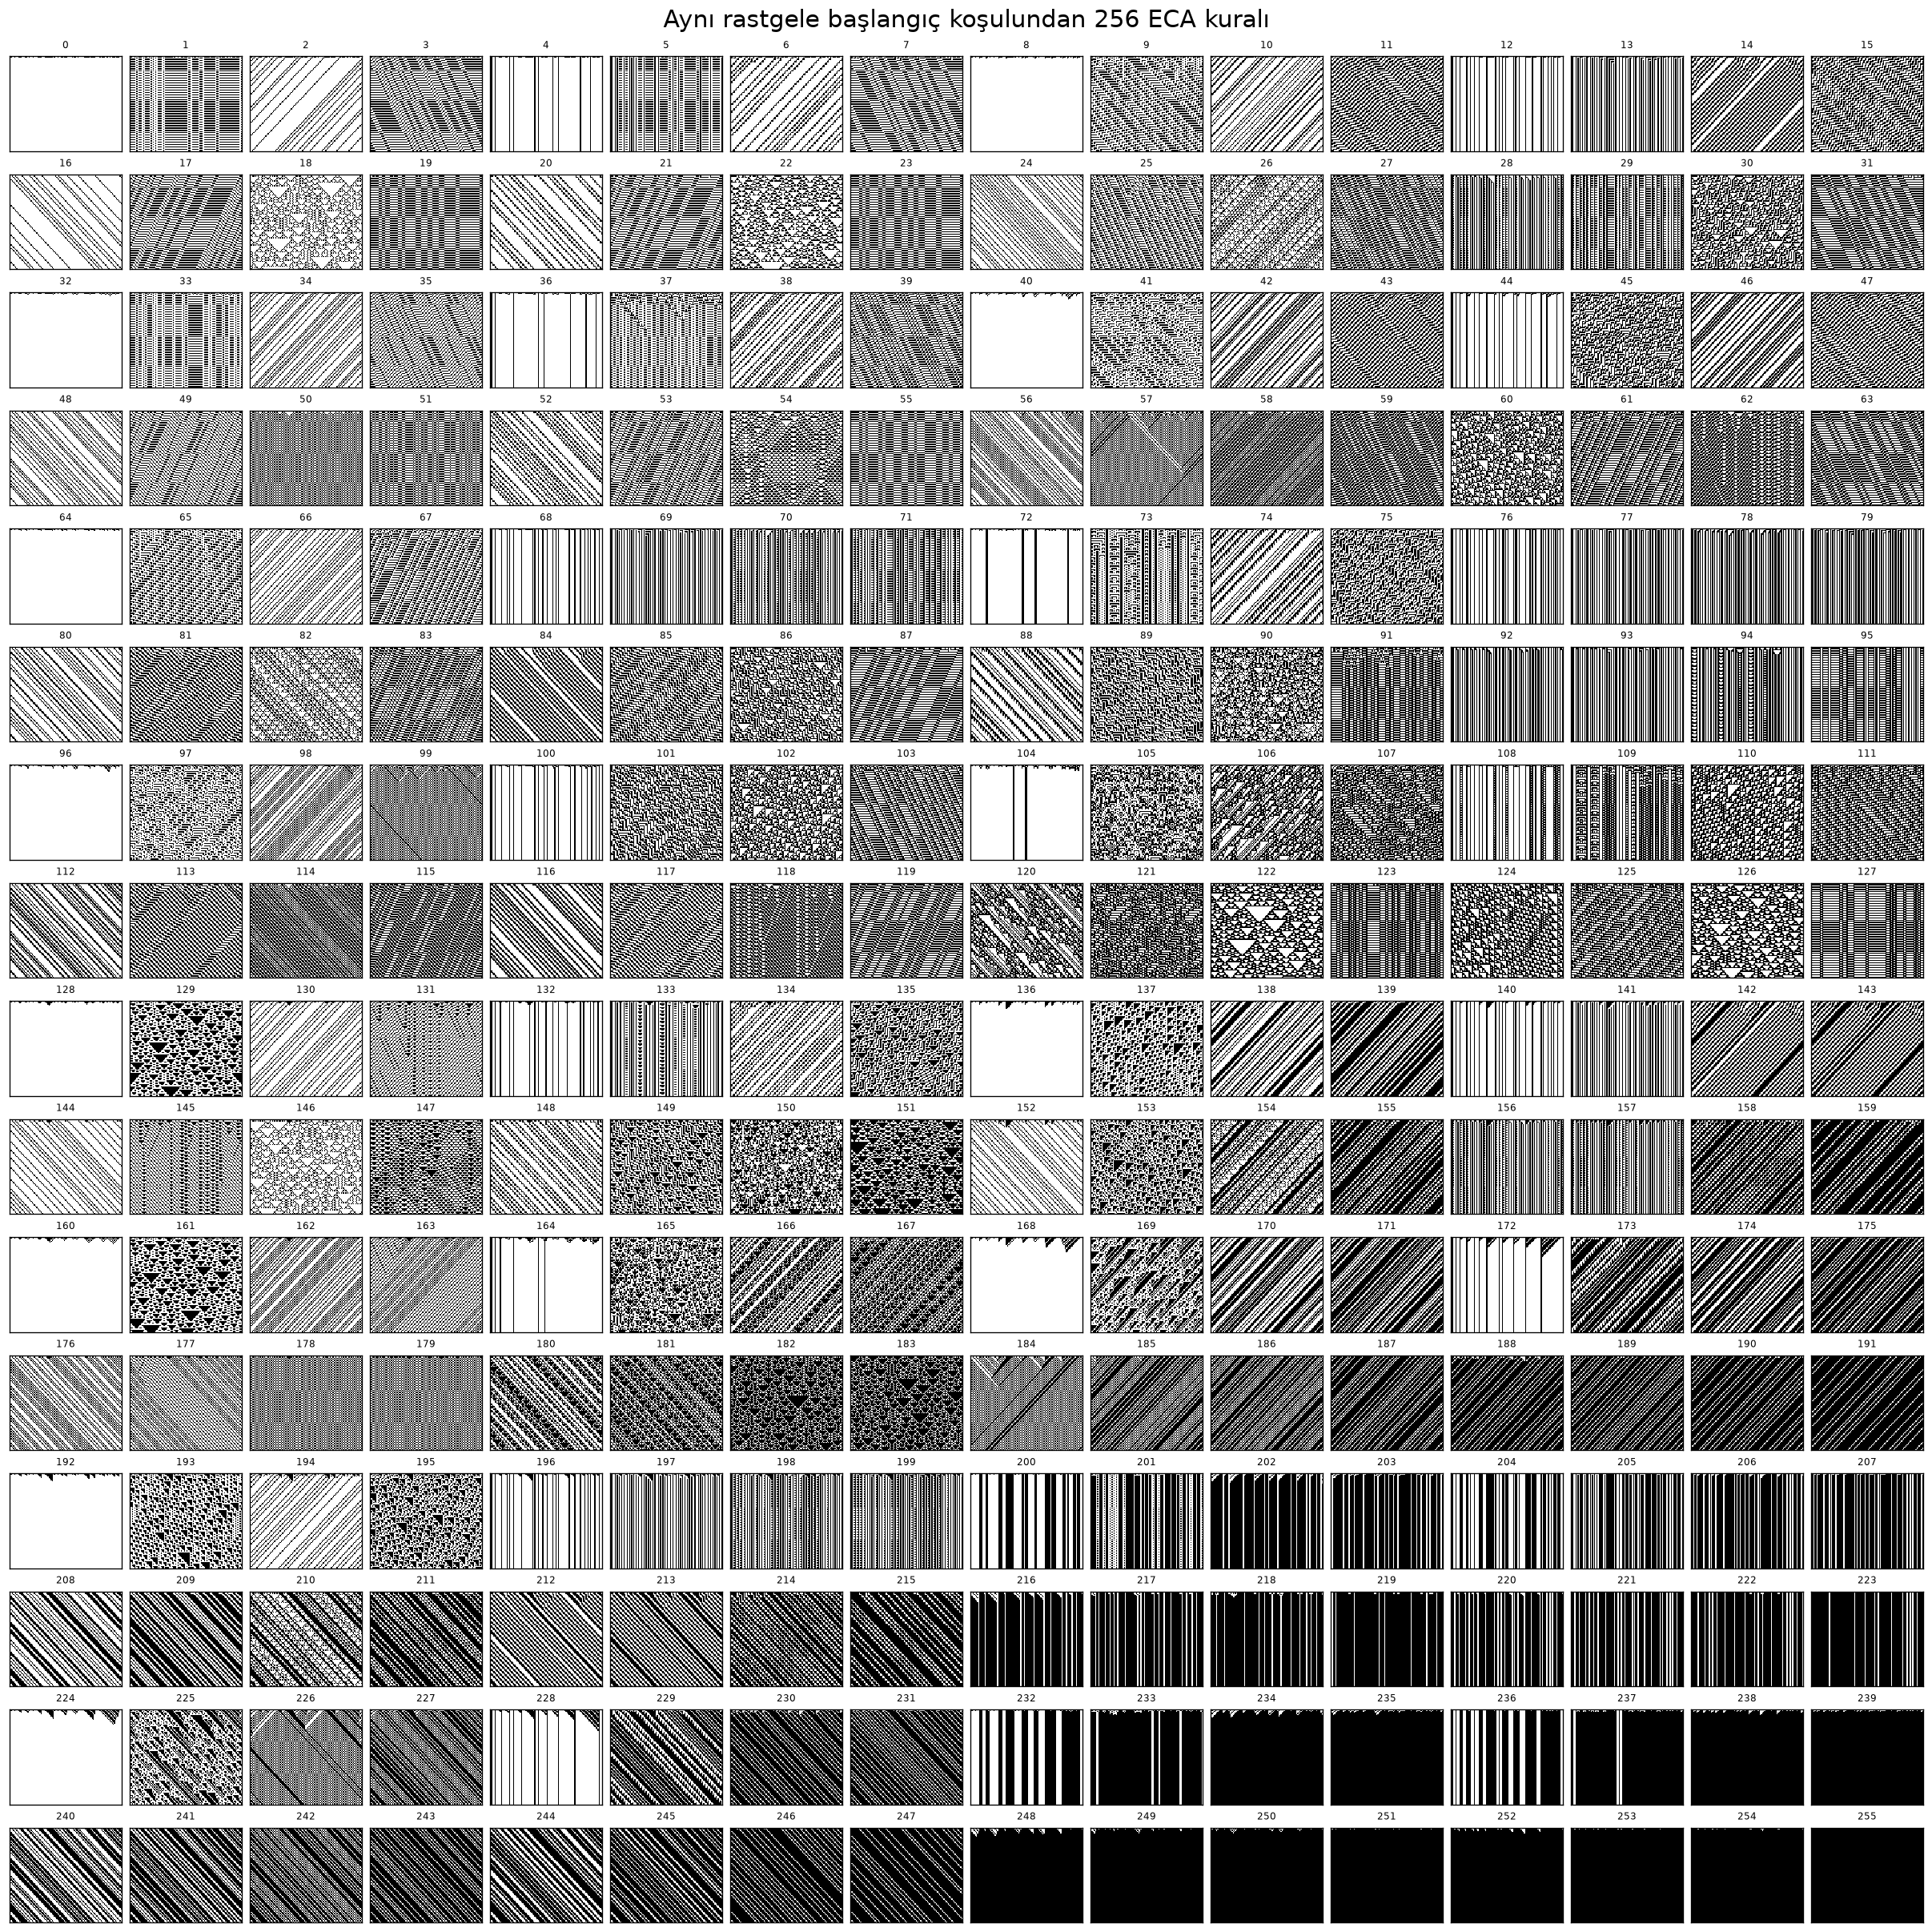

In [6]:
gallery_width = 101
gallery_steps = 80
gallery_density = 0.5

gallery_initial = _random_initial_state_reference(
    gallery_width, gallery_density, np.random.default_rng(42)
)

fig, axes = plt.subplots(16, 16, figsize=(20, 20), constrained_layout=True)

for rule, ax in enumerate(axes.flat):
    history = simulate(gallery_initial, rule, gallery_steps)
    ax.imshow(history, interpolation="nearest", aspect="auto", vmin=0, vmax=1)
    ax.set_title(str(rule), fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Aynı rastgele başlangıç koşulundan 256 ECA kuralı", fontsize=18)
plt.show()

### Galeri gozlemi

Galeriyi buyuterek incele ve asagidakileri doldur:

- Hizla homojenlesen uc kural: `0, 8, 32`
- Acikca tekrarlanan desen gosteren uc kural: `4, 12, 94`
- Duzensiz gorunen uc kural: `30, 45, 60`
- Siniflandirmakta en cok zorlandigim uc kural: `54, 73, 184`

**Ilk gozlem notlarim:**

> Kural 0, 8 ve 32'de galeri neredeyse tamamen bos/beyaz gorunuyor.
>
> Kural 94'te galeri, sabit genislikte dikey seritler gosteriyor; donuk/duzenli bir izlenim veriyor. Kural 4 ve 12'de de benzer sekilde birkac dikey cizgiye kilitlenmis bir goruntu var.
>
> Kural 30, 45 ve 60 galeri karesinde duzensiz, tekrarsiz gorunen bir doku dolduruyor.
>
> En cok zorlandigim kurallar Kural 54, 73 ve 184 oldu: goruntu ne tamamen donuk ne de tamamen gurultulu. Kesin bir etiket koymuyorum; asil siniflandirmayi ikinci yarida yogunluk/etkinlik olcumleriyle birlikte yapacagiz.

<details>
<summary>Kontrol sorusu: Galerideki 256 kucuk resmi ayri deneyler olarak dusunebilir miyiz?</summary>

Evet; ancak kontrollu deneylerdir. Baslangic durumu, genislik, sure ve sinir kosulu aynidir. Yalnizca kural numarasi degistirilmistir.
</details>


## 5. İlk gözlenebilir: yoğunluk

Bir satırdaki dolu hücrelerin oranına yoğunluk diyoruz:

\[
\rho(t)=\frac{1}{N}\sum_{i=1}^{N}s_i(t).
\]

`history` dizisinin her satırı bir zamanı temsil ettiği için, her satırın ortalamasını almalıyız.

### Alıştırma 2

`density_time_series` fonksiyonunu tamamla. Sonucun uzunluğu zaman adımı sayısına eşit olmalı.

In [ ]:
def density_time_series(history):
    '''Her zaman adımındaki dolu hücre oranını döndür.'''
    history = np.asarray(history)
    # TODO: axis=1 boyunca ortalama al
    return np.zeros(history.shape[0])

In [ ]:
def test_density_time_series():
    example = np.array([
        [0, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 1, 0],
        [1, 1, 1, 1],
    ])
    result = density_time_series(example)
    expected = np.array([0.0, 0.25, 0.5, 1.0])
    assert result.shape == (4,), f"beklenen biçim (4,), bulunan {result.shape}"
    assert np.allclose(result, expected), f"beklenen {expected}, bulunan {result}"


check("Alıştırma 2 — yoğunluk", test_density_time_series)

## 6. İkinci gözlenebilir: etkinlik

Yoğunluk, hücrelerin **nerede** olduğunu veya zaman içinde değişip değişmediğini söylemez. Bu nedenle ardışık iki satır arasında değişen hücrelerin oranını ölçelim:

\[
a(t)=\frac{1}{N}\sum_{i=1}^{N}|s_i(t+1)-s_i(t)|.
\]

- \(a(t)=0\): hiçbir hücre değişmemiştir;
- \(a(t)=1\): her hücre durum değiştirmiştir.

`np.diff(history, axis=0)` ardışık satırların farkını verir. Fakat `uint8` türünde negatif sayılar taşabileceği için önce diziyi işaretli tam sayıya dönüştür.

### Alıştırma 3

`activity_time_series` fonksiyonunu tamamla. Sonucun uzunluğu `steps - 1` olacaktır.

In [ ]:
def activity_time_series(history):
    '''Ardışık zamanlarda değişen hücrelerin oranını döndür.'''
    history = np.asarray(history, dtype=int)
    # TODO: np.diff, np.abs ve axis=1 boyunca ortalamayı kullan
    return np.zeros(history.shape[0] - 1)

In [ ]:
def test_activity_time_series():
    example = np.array([
        [0, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 1, 0],
        [0, 1, 0, 1],
    ], dtype=np.uint8)
    result = activity_time_series(example)
    expected = np.array([0.25, 0.25, 1.0])
    assert result.shape == (3,), f"beklenen biçim (3,), bulunan {result.shape}"
    assert np.allclose(result, expected), f"beklenen {expected}, bulunan {result}"


check("Alıştırma 3 — etkinlik", test_activity_time_series)

### Ölçümler için referans fonksiyonları

Sonraki karşılaştırma şekli, alıştırmalar bitmeden de çalışabilmesi için referans fonksiyonlarını kullanır. Testlerin geçtikten sonra aşağıdaki fonksiyonları kendi fonksiyonlarınla değiştirip şeklin aynı kaldığını kontrol et.

In [ ]:
def _density_reference(history):
    return np.asarray(history).mean(axis=1)


def _activity_reference(history):
    signed = np.asarray(history, dtype=int)
    return np.abs(np.diff(signed, axis=0)).mean(axis=1)

## 7. Aynı yoğunluk, farklı dinamik

Aşağıda farklı davranış türlerinden sekiz kuralı aynı başlangıç koşuluyla karşılaştırıyoruz:

```python
[0, 4, 30, 54, 90, 110, 126, 184]
```

Üst panel yoğunluğu, alt panel etkinliği gösterir. Eğrileri çizmeden önce şu tahmini yap:

> Hangi kuralların uzun-zaman etkinliğinin sıfıra yaklaşmasını bekliyorum ve neden?

In [ ]:
representative_rules = [0, 4, 30, 54, 90, 110, 126, 184]
measurement_steps = 150
measurement_initial = _random_initial_state_reference(
    201, 0.5, np.random.default_rng(42)
)

fig, (ax_density, ax_activity) = plt.subplots(
    2, 1, figsize=(11, 8), sharex=True, constrained_layout=True
)

for rule in representative_rules:
    history = simulate(measurement_initial, rule, measurement_steps)
    ax_density.plot(_density_reference(history), label=f"Kural {rule}")
    ax_activity.plot(_activity_reference(history), label=f"Kural {rule}")

ax_density.set(ylabel=r"Yoğunluk $\rho(t)$", title="Yoğunluk ve etkinlik karşılaştırması")
ax_activity.set(xlabel="Zaman adımı", ylabel=r"Etkinlik $a(t)$")
ax_density.grid(alpha=0.25)
ax_activity.grid(alpha=0.25)
ax_density.legend(ncol=4, fontsize=8)
plt.show()

### Şekli yorumla

Aşağıdaki soruları şekilden **sayısal veya görsel kanıt vererek** yanıtla:

1. Benzer yoğunluğa sahip fakat farklı etkinlik gösteren iki kural bul.
2. Hangi kurallar sabit veya periyodik bir davranışa yaklaşıyor gibi görünüyor?
3. Yüksek etkinlik bir kuralın mutlaka Sınıf III olduğu anlamına gelir mi?
4. Tek başına yoğunluk, Kural 30 ile Kural 110'u güvenilir biçimde ayırabilir mi?

**Yanıtlarım:**

> Buraya en az 6–10 cümle yaz.

<details>
<summary>İpucu: Yoğunluk ve etkinlik neden birlikte daha yararlı?</summary>

Yoğunluk toplam dolu hücre oranını, etkinlik ise zaman içinde değişen hücre oranını ölçer. Aynı yoğunluğa sahip iki sistemden biri donmuş, diğeri hızla değişiyor olabilir. İki ölçüm birlikte kullanıldığında daha fazla bilgi taşır; yine de uzamsal düzenin tamamını göstermez.
</details>

## 8. Başlangıç koşuluna bağımlılık

Bir kuralı yalnızca tek bir başlangıç durumuyla sınıflandırmak risklidir. Şimdi aynı kuralı iki başlangıçtan çalıştıracağız:

1. merkezde tek dolu hücre;
2. \(p=0.5\) yoğunluklu rastgele satır.

### Alıştırma 4

Aşağıdaki fonksiyonda iki benzetimi tamamla. Fonksiyon, iki geçmişi bir demet (`tuple`) olarak döndürmeli.

In [ ]:
def compare_initial_conditions(rule_number, width, steps, seed=42):
    '''Aynı kuralı tek-tohum ve rastgele başlangıçlardan çalıştır.'''
    one_cell = single_seed(width)
    random_row = _random_initial_state_reference(
        width, 0.5, np.random.default_rng(seed)
    )

    # TODO: iki başlangıç için simulate(...) çağrısı yap
    history_single = np.zeros((steps, width), dtype=np.uint8)
    history_random = np.zeros((steps, width), dtype=np.uint8)
    return history_single, history_random

In [ ]:
def test_compare_initial_conditions():
    single, random = compare_initial_conditions(90, width=31, steps=12, seed=7)
    assert single.shape == (12, 31) and random.shape == (12, 31), (
        "iki geçmiş de (steps, width) biçiminde olmalı"
    )
    assert single[0].sum() == 1, "ilk geçmiş tek dolu hücreyle başlamalı"
    assert 1 < random[0].sum() < 30, "ikinci geçmiş rastgele bir satırla başlamalı"
    assert np.array_equal(single[1], update_row(single[0], 90)), (
        "tek-hücre geçmişi Kural 90 ile ilerlemeli"
    )
    assert np.array_equal(random[1], update_row(random[0], 90)), (
        "rastgele geçmiş Kural 90 ile ilerlemeli"
    )


check("Alıştırma 4 — başlangıç koşulları", test_compare_initial_conditions)

### Karşılaştırma şekli

Testin geçtikten sonra aşağıdaki `simulate` çağrılarını kendi `compare_initial_conditions` fonksiyonunla değiştirmeyi dene.

In [ ]:
rules_to_compare = [4, 30, 90, 110]
comparison_width = 121
comparison_steps = 80
random_comparison_initial = _random_initial_state_reference(
    comparison_width, 0.5, np.random.default_rng(42)
)

fig, axes = plt.subplots(4, 2, figsize=(12, 13), constrained_layout=True)

for row_index, rule in enumerate(rules_to_compare):
    histories = [
        simulate(single_seed(comparison_width), rule, comparison_steps),
        simulate(random_comparison_initial, rule, comparison_steps),
    ]
    for column_index, history in enumerate(histories):
        ax = axes[row_index, column_index]
        ax.imshow(history, interpolation="nearest", aspect="auto", vmin=0, vmax=1)
        ax.set_title(
            f"Kural {rule} — " + ("tek hücre" if column_index == 0 else "rastgele")
        )
        ax.set_xticks([])
        ax.set_yticks([])

plt.show()

### Başlangıç koşulu karşılaştırmasını yorumla

Her kural için iki şeklin ortak ve farklı yönlerini yaz:

| Kural | Tek hücre başlangıcı | Rastgele başlangıç | Sınıflandırmam değişti mi? |
|---:|---|---|---|
| 4 | | | |
| 30 | | | |
| 90 | | | |
| 110 | | | |

<details>
<summary>Soru: Kural mı, başlangıç koşulu mu daha önemlidir?</summary>

Genel bir “biri her zaman daha önemlidir” yanıtı yoktur. Gözlenen yörünge ikisinin birleşimidir. Kontrollü bir deneyde hangisini değiştirdiğimizi açıkça söylemeliyiz.
</details>

## 9. Sınıflandırma tablosu — ana ödev

Aşağıdaki 16 kuralı galeriden ve ölçüm grafiklerinden incele:

```python
[0, 4, 8, 18, 22, 30, 45, 54, 60, 73, 90, 94, 110, 126, 150, 184]
```

Her kural için **geçici** bir sınıf öner. Kararsızsan `II/IV?` gibi bir etiket kullanabilirsin; belirsizliği dürüstçe belirtmek bilimsel bir davranıştır. Kanıt sütununa yalnızca “öyle görünüyor” yazma. Tekrar, simetri, uzun-zaman yoğunluğu, etkinlik veya yerel yapı gibi gözlenebilir bir özellik belirt.

| Kural | Önerilen sınıf | Görsel kanıt | Ölçümsel kanıt | Güvenim (düşük/orta/yüksek) |
|---:|:---:|---|---|:---:|
| 0 | | | | |
| 4 | | | | |
| 8 | | | | |
| 18 | | | | |
| 22 | | | | |
| 30 | | | | |
| 45 | | | | |
| 54 | | | | |
| 60 | | | | |
| 73 | | | | |
| 90 | | | | |
| 94 | | | | |
| 110 | | | | |
| 126 | | | | |
| 150 | | | | |
| 184 | | | | |

### Sınıflandırma yönteminin sınırları

Şu soruya 5–8 cümleyle yanıt ver:

> Sonlu süreli tek bir benzetimden bir ECA kuralına kesin sınıf etiketi vermek neden zor olabilir?

## 10. İsteğe bağlı ileri araştırma: 256 kuralın ölçüm haritası

Zamanın kalırsa her kural için geçici ilk 50 adımı atıp kalan zamanda ortalama yoğunluk ve ortalama etkinlik hesapla:

\[
\bar\rho=\frac{1}{T-50}\sum_{t=50}^{T-1}\rho(t),
\qquad
\bar a=\frac{1}{T-51}\sum_{t=50}^{T-2}a(t).
\]

Sonra 256 noktayı \((\bar\rho,\bar a)\) düzleminde çiz. Yakın noktalar mutlaka aynı görsel sınıfta mı?

Bu bölüm isteğe bağlıdır; aşağıdaki iskeleti tamamlayabilirsin.

In [ ]:
# İSTEĞE BAĞLI
# mean_densities = []
# mean_activities = []
#
# for rule in range(256):
#     history = simulate(gallery_initial, rule, steps=200)
#     # TODO: ilk 50 adımı at ve uzun-zaman ortalamalarını listelere ekle
#
# fig, ax = plt.subplots(figsize=(8, 6))
# ax.scatter(mean_densities, mean_activities, s=18, alpha=0.7)
# ax.set(xlabel="Ortalama yoğunluk", ylabel="Ortalama etkinlik")
# plt.show()

## 11. Sonuç ve haftalık kontrol noktası

### Çıkış sorusu

Aşağıdaki soruya 5–7 cümleyle yanıt ver:

> Görsel sınıflandırma, yoğunluk ve etkinlik ölçümleri birbirini nasıl tamamlar? Bunlardan herhangi biri tek başına bir hücresel otomatın davranışını eksiksiz tanımlar mı?

**Yanıtım:**

> Buraya yaz.

### Görüşmeye getirilecekler

- dört alıştırma testinin geçmesi;
- 256-kural galerisi;
- doldurulmuş 16-kural sınıflandırma tablosu;
- yoğunluk ve etkinlik karşılaştırma şekli;
- iki başlangıç koşulunu karşılaştıran şekil ve tablo;
- deneyden önceki tahminlerinle sonuçların arasındaki fark;
- tartışmak istediğin **iki soru**.

### GitHub teslimi

Dosya adı:

```text
02_rule_classification.ipynb
```

Önerilen kayıt mesajı:

```text
2. Hafta: CA sınıflandırması
```

**Teslimden önce:** `Restart Kernel and Run All Cells` çalıştır. Test çıktılarını ve şekilleri not defterinde bırak. Ardından GitHub'a gönder.